In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data\SolarMeterReadings1hour.csv")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def drop_days_without_noon(
    df,
    ts_col="timestamp",         # timestamp column
    meter_col="meter",          # meter id/name column
    tolerance="30min"           # allow ± this window around 12:00 (use "0min" for exact 12:00)
):
    """
    Leave timestamps exactly as they are (no timezone changes).
    Keep only rows from (meter, date) pairs that have at least one sample within
    noon ± tolerance. Everything else for that day is removed.
    """
    out = df.copy()

    # 1) Parse datetimes, keep only valid timestamps
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")
    out = out.dropna(subset=[ts_col])

    # 2) Compute calendar date and distance to that date’s 12:00
    #    (normalize keeps tz if present; if naive, stays naive. No conversions.)
    midday = out[ts_col].dt.normalize() + pd.Timedelta(hours=12)
    out["date"] = out[ts_col].dt.date
    out["noon_gap"] = (out[ts_col] - midday).abs()
    tol = pd.Timedelta(tolerance)

    # 3) For each (meter, date), check if any record falls within noon ± tolerance
    has_noon = (
        out.groupby([meter_col, "date"])["noon_gap"]
           .min()
           .le(tol)
           .rename("has_noon")
           .reset_index()
    )

    # 4) Split into bad dates and cleaned data
    out = out.merge(has_noon, on=[meter_col, "date"], how="left")
    bad_dates = (
        out[~out["has_noon"].fillna(False)][[meter_col, "date"]]
        .drop_duplicates()
        .sort_values([meter_col, "date"])
        .reset_index(drop=True)
    )

    df_clean = (
        out[out["has_noon"].fillna(False)]
        .drop(columns=["noon_gap", "has_noon"])
        .sort_values([meter_col, ts_col])
        .reset_index(drop=True)
    )
    return df_clean, bad_dates


def plot_cleaned_data(df_clean,
                      meter_id,
                      ts_col="timestamp",
                      meter_col="meter",
                      y_col="meter_reading"):
    """
    Quick sanity plot of the CLEANED data for a single meter.
    """
    d = df_clean[df_clean[meter_col] == meter_id].sort_values(ts_col)
    if d.empty:
        print(f"No cleaned data for meter '{meter_id}'.")
        return

    plt.figure(figsize=(12, 4))
    plt.plot(d[ts_col], d[y_col], linewidth=1.0)
    plt.title(f"Cleaned data (kept days only) — Meter: {meter_id}")
    plt.xlabel("Time")
    plt.ylabel(y_col)
    plt.grid(True, linestyle="--", alpha=0.3)
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.tight_layout()
    plt.show()


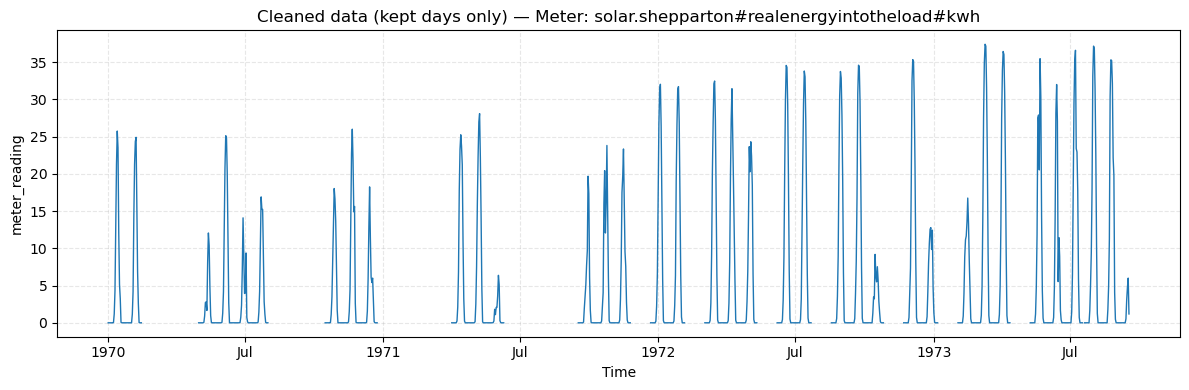

In [24]:
df_sub = df[(df['meter']=="solar.shepparton#realenergyintotheload#kwh") & (df['timestamp'] > '2025-07-01 00:00:00')]



df_clean, bad_dates = drop_days_without_noon(df_sub)

# print(df_fil)

# x = [x for x in range (len(df_fil))]

plot_cleaned_data(df_clean, meter_id="solar.shepparton#realenergyintotheload#kwh",
                  ts_col="timestamp", meter_col="meter", y_col="meter_reading")

In [31]:
import numpy as np
import sys
np.set_printoptions(threshold=sys.maxsize)

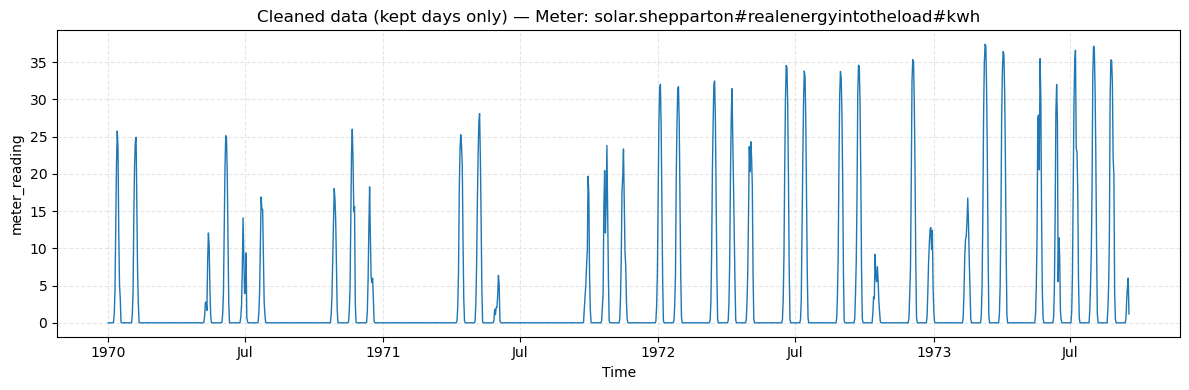

In [35]:
df_clean_nan = df_clean.dropna(subset=['meter_reading'])
plot_cleaned_data(df_clean_nan, meter_id="solar.shepparton#realenergyintotheload#kwh",
                  ts_col="timestamp", meter_col="meter", y_col="meter_reading")

In [37]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [38]:
df_clean_nan

,timestamp,meter_reading,meter,date
0,2025-07-01 01:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
1,2025-07-01 02:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
2,2025-07-01 03:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
3,2025-07-01 04:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
4,2025-07-01 05:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
5,2025-07-01 06:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
6,2025-07-01 07:00:00,0.00000,solar.shepparton#realenergyintotheload#kwh,2025-07-01
7,2025-07-01 08:00:00,0.03125,solar.shepparton#realenergyintotheload#kwh,2025-07-01
8,2025-07-01 09:00:00,1.18750,solar.shepparton#realenergyintotheload#kwh,2025-07-01
9,2025-07-01 10:00:00,4.31250,solar.shepparton#realenergyintotheload#kwh,2025-07-01
